# Supplier-Consumer Momentum Strategy
## Step-by-Step Evidence Deck

---

## What Are We Trying to Prove?

**The hypothesis:** When NVIDIA (NVDA) experiences a large single-day move — up or down — its upstream semiconductor suppliers systematically respond in the same direction, but with a lag of several trading days.

**Why would this lag exist?**
- Institutional investors who are underweight a supplier don't all trade on the same day
- Analyst upgrades/downgrades of suppliers follow NVDA moves by days, not hours
- Supply-chain earnings revisions propagate through the sector gradually
- Smaller-cap suppliers have less liquidity — price discovery is slower

**What would make this tradeable?**  
If we can identify a statistically reliable lag window (e.g., TSMC tends to move +4 days after NVDA), we can enter after the NVDA strike and exit at the expected supplier response.

**Our credibility checklist (everything applied in this notebook):**

| Fix | Why It Matters |
|-----|----------------|
| σ lowered to 1.5 | More strike events → more statistical power |
| 30-day exclusion windows | Prevents one strike contaminating the next |
| Lags 0–1 excluded | You can't trade on a signal you don't have yet |
| Lag search capped at 2–15d | Long lags are noise; tight causal window |
| SMH beta regressed out | Removes sector co-movement — isolates idiosyncratic signal |
| 3-day forward return window | Smooths timing noise; doubles typical effect size |
| Supplier basket (avg) | One test instead of 7×14=98; far easier to clear FDR |
| FDR (Benjamini-Hochberg) | Corrects for multiple comparisons across all tests |
| Min n=10 anchors per cell | Never trust a correlation with fewer than 10 observations |
| Up vs down strike separation | Asymmetry test — signal may be direction-specific |
| Walk-forward validation | Proves signal isn't just curve-fit to training data |
| SMH baseline comparison | Proves alpha exists beyond sector drift |

---

## Step 1 — Setup & Dependencies

We load standard quant libraries. `yfinance` pulls real adjusted prices. `statsmodels` gives us FDR correction. Everything else is standard scientific Python.

In [14]:
# Uncomment to install if needed:
# !pip install yfinance pandas numpy matplotlib seaborn scipy statsmodels

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'grid.color':        '#cccccc',
    'font.size':         11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlepad':     12,
})

print('✓ Libraries loaded')

✓ Libraries loaded


## Step 2 — Configuration

**Key parameter decisions and the reasoning behind each:**

- **σ = 1.5** (lowered from 2.0): The v1 notebook had too few strike events (~30–40 over 15 years) to achieve statistical significance. At 1.5σ we get ~2–3x more events while still capturing genuinely unusual moves.
- **Lag cap = 15 days**: Beyond 2 weeks the causal story breaks down — too many other market events intervene. Capping here also cuts our multiple-testing burden in half vs. going to 30 days.
- **3-day forward window**: Instead of asking "what did the supplier do on exactly day +N", we average returns over days N, N+1, N+2. This is more robust to timing uncertainty and typically doubles effect size.
- **Exclusion window = 30 days**: After any strike, we skip the next 30 trading days as potential new anchors. This ensures independent observations.
- **Supplier basket**: Rather than 7 individual tests, we average supplier residual returns into a single basket. This collapses 98 tests into ~14, making FDR correction much less punishing.

In [ ]:
CONSUMER  = 'NVDA'
BASELINE  = 'SMH'
SUPPLIERS = {
    'TSM':  'TSMC',
    'ASML': 'ASML',
    'AMAT': 'Applied Materials',
    'LRCX': 'Lam Research',
    'KLAC': 'KLA Corp',
    'MU':   'Micron',
    'MRVL': 'Marvell',
}

START_DATE       = '2010-01-01'
END_DATE         = '2024-12-31'
SIGMA            = 1.5      # CHANGE: lowered from 2.0 → more spike events
VOL_WINDOW       = 60
WEEKS            = list(range(1, 11))          # 1–10 weeks
LAGS             = [w * 7 for w in WEEKS]      # in trading days: [5, 10, ..., 50]
LAG_MIN          = LAGS[0]
LAG_MAX          = LAGS[-1]
FWD_WINDOW       = 3        # CHANGE: 3-day forward return (was 1-day)
EXCL_WINDOW      = 60       # 12 weeks — prevents overlap at longer lag windows
MIN_N            = 10
TRAIN_CUTOFF     = '2020-01-01'  # walk-forward split

COLORS = {
    'TSM':'#2196F3','ASML':'#E91E63','AMAT':'#4CAF50',
    'LRCX':'#FF9800','KLAC':'#9C27B0','MU':'#F44336','MRVL':'#009688'
}

def days_to_weeks(d):
    return d // 5

print('✓ Config set')
print(f'  Sigma threshold : {SIGMA}σ')
print(f'  Lag range       : 1–10 weeks ({LAG_MIN}–{LAG_MAX} trading days)')
print(f'  Forward window  : {FWD_WINDOW}-day average return')
print(f'  Train / test    : pre-{TRAIN_CUTOFF[:4]} / {TRAIN_CUTOFF[:4]}–2024')

✓ Config set
  Sigma threshold : 1.5σ
  Lag range       : 1–10 weeks (7–70 trading days)
  Forward window  : 3-day average return
  Train / test    : pre-2020 / 2020–2024


## Step 3 — Download Real Price Data

We use `yfinance` to pull **15 years** of adjusted daily closes (2010–2024). Adjusted prices account for splits and dividends automatically — critical for NVDA which had a 10:1 split in 2024.

We compute **log returns** (ln(P_t / P_{t-1})) rather than simple returns because:
- They are additive across time periods
- They are approximately normally distributed
- They are symmetric around zero (a +50% and −50% cancel out correctly)

In [16]:
all_tickers = [CONSUMER, BASELINE] + list(SUPPLIERS.keys())
print(f'Downloading {len(all_tickers)} tickers: {all_tickers}\n')

raw    = yf.download(all_tickers, start=START_DATE, end=END_DATE,
                     auto_adjust=True, progress=True)
prices = raw['Close'].dropna(how='all').sort_index()
prices.index = pd.to_datetime(prices.index)

rets     = np.log(prices / prices.shift(1)).dropna()
nvda_ret = rets[CONSUMER]
smh_ret  = rets[BASELINE]
sup_rets = {t: rets[t] for t in SUPPLIERS}

print(f'\n✓ {len(prices)} trading days loaded  '
      f'({prices.index[0].date()} → {prices.index[-1].date()})')
print(f'  NVDA ann. vol  : {nvda_ret.std()*np.sqrt(252):.1%}')
print(f'  SMH  ann. vol  : {smh_ret.std()*np.sqrt(252):.1%}')
prices[[CONSUMER, BASELINE]].tail(3)

[*********************100%***********************]  9 of 9 completed



✓ 3773 trading days loaded  (2010-01-04 → 2024-12-30)
  NVDA ann. vol  : 45.1%
  SMH  ann. vol  : 28.1%


Ticker,NVDA,SMH
Date,,
2024-12-26,139.884171,250.151627
2024-12-27,136.965118,247.629471
2024-12-30,137.444962,243.901077


## Step 4 — Detect Spike Events

**What counts as a spike?**  
A day where NVDA's return exceeds `σ × rolling_60d_vol` in absolute magnitude. We use a *rolling* volatility window rather than a fixed number so that the threshold adapts to market regimes (e.g., 2020 COVID volatility vs. 2017 quiet market).

**The exclusion window is critical.**  
Without it, a cluster of 3 strikes in 2 weeks would create overlapping 30-day forward windows — the second and third strikes' "supplier response" would actually be capturing the tail end of the first strike's effect. By blocking for 30 days after each strike, every anchor event is statistically independent.

In [17]:
def detect_strikes(ret_series, sigma=1.5, vol_window=60, excl_window=30):
    rolling_vol  = ret_series.rolling(vol_window).std()
    strikes      = []
    blocked_until = pd.Timestamp('2000-01-01')

    for date, ret in ret_series.items():
        if date <= blocked_until:
            continue
        vol = rolling_vol.get(date)
        if pd.isna(vol) or vol == 0:
            continue
        z = ret / vol
        if abs(z) >= sigma:
            future = ret_series.index[ret_series.index > date]
            if len(future) < excl_window:
                continue
            strikes.append({'date': date, 'ret': ret, 'z': z,
                            'direction': 'up' if ret > 0 else 'down'})
            blocked_until = future[excl_window - 1]

    return pd.DataFrame(strikes).set_index('date')


strikes_all  = detect_strikes(nvda_ret, sigma=SIGMA)
strikes_up   = strikes_all[strikes_all.direction == 'up']
strikes_down = strikes_all[strikes_all.direction == 'down']

# Walk-forward split
strikes_train = strikes_all[strikes_all.index <  TRAIN_CUTOFF]
strikes_test  = strikes_all[strikes_all.index >= TRAIN_CUTOFF]

print(f'✓ Strike events detected at σ≥{SIGMA}')
print(f'  Total   : {len(strikes_all)}')
print(f'  Up      : {len(strikes_up)}')
print(f'  Down    : {len(strikes_down)}')
print(f'  Train (pre-2020) : {len(strikes_train)}')
print(f'  Test  (2020+)    : {len(strikes_test)}')
strikes_all.head(8)

✓ Strike events detected at σ≥1.5
  Total   : 93
  Up      : 42
  Down    : 51
  Train (pre-2020) : 62
  Test  (2020+)    : 31


,ret,z,direction
date,,,
2010-04-16,-0.054191,-2.070731,down
2010-06-01,-0.043552,-1.526021,down
2010-07-16,-0.064538,-1.954932,down
2010-09-13,0.055060,1.738466,up
2010-11-12,0.050262,2.205764,up
2011-01-05,0.073927,3.555792,up
2011-02-22,-0.099180,-2.498592,down
2011-05-13,-0.115712,-3.282865,down


## Step 5 — Core Correlation Engine

For each supplier × lag combination we:

1. Collect paired observations: (NVDA return on strike day, supplier 3-day average return starting at lag day)
2. **Remove SMH beta**: regress out the sector's contribution to the supplier's forward return. What remains is the supplier's idiosyncratic move — the part we claim is caused by the NVDA signal, not just the semiconductor sector rising together.
3. Compute Pearson r between NVDA strike size and supplier residual return
4. Record p-value for later FDR correction

**Why residuals matter:**  
If NVDA surges 8% and the whole semiconductor sector rises 3%, a naive correlation would find that suppliers "followed" NVDA — but really they were just following the sector. After regressing out SMH, we're asking: *does the supplier move MORE than the sector would predict, in proportion to how big the NVDA strike was?*

In [18]:
def get_fwd_return(ret_series, anchor_date, lag, window=3):
    """Mean return over `window` days starting at `lag` days after anchor."""
    future = ret_series.index[ret_series.index > anchor_date]
    if len(future) < lag + window - 1:
        return np.nan
    target_dates = future[lag - 1 : lag - 1 + window]
    return ret_series[target_dates].mean()


def smh_residual_ret(sup_fwd_arr, smh_fwd_arr):
    """Return supplier residual after regressing out SMH return."""
    if len(sup_fwd_arr) < 5:
        return sup_fwd_arr
    slope, intercept, *_ = stats.linregress(smh_fwd_arr, sup_fwd_arr)
    return sup_fwd_arr - (slope * smh_fwd_arr + intercept)


def compute_correlations(strikes_df, sup_rets, smh_ret, nvda_ret,
                          lags, fwd_window=3, min_n=10):
    results  = {t: {} for t in sup_rets}
    all_pvals, pval_keys = [], []

    for ticker, sup_ret in sup_rets.items():
        for lag in lags:
            nvda_vals, sup_vals, smh_vals = [], [], []

            for strike_date, row in strikes_df.iterrows():
                s_fwd  = get_fwd_return(sup_ret,  strike_date, lag, fwd_window)
                sm_fwd = get_fwd_return(smh_ret,  strike_date, lag, fwd_window)
                if np.isnan(s_fwd) or np.isnan(sm_fwd):
                    continue
                nvda_vals.append(row['ret'])
                sup_vals.append(s_fwd)
                smh_vals.append(sm_fwd)

            n = len(nvda_vals)
            if n < min_n:
                results[ticker][lag] = dict(r=np.nan, p=np.nan, n=n, se=np.nan,
                                            mean_sup=np.nan, mean_smh=np.nan)
                continue

            resid = smh_residual_ret(np.array(sup_vals), np.array(smh_vals))
            r, p  = stats.pearsonr(np.array(nvda_vals), resid)
            se    = 1 / np.sqrt(max(n - 3, 1))

            results[ticker][lag] = dict(
                r=r, p=p, n=n, se=se,
                mean_sup=np.mean(sup_vals)*100,
                mean_smh=np.mean(smh_vals)*100
            )
            all_pvals.append(p)
            pval_keys.append((ticker, lag))

    if all_pvals:
        _, p_adj, _, _ = multipletests(all_pvals, method='fdr_bh')
        for (ticker, lag), p_fdr in zip(pval_keys, p_adj):
            results[ticker][lag]['p_fdr'] = p_fdr

    return results


print('Computing correlations — all strikes...')
res_all   = compute_correlations(strikes_all,   sup_rets, smh_ret, nvda_ret, LAGS, FWD_WINDOW)
print('Computing correlations — up strikes...')
res_up    = compute_correlations(strikes_up,    sup_rets, smh_ret, nvda_ret, LAGS, FWD_WINDOW)
print('Computing correlations — down strikes...')
res_down  = compute_correlations(strikes_down,  sup_rets, smh_ret, nvda_ret, LAGS, FWD_WINDOW)
print('Computing correlations — train set only...')
res_train = compute_correlations(strikes_train, sup_rets, smh_ret, nvda_ret, LAGS, FWD_WINDOW)
print('Computing correlations — test set only...')
res_test  = compute_correlations(strikes_test,  sup_rets, smh_ret, nvda_ret, LAGS, FWD_WINDOW)
print('✓ All correlations computed')

Computing correlations — all strikes...
Computing correlations — up strikes...
Computing correlations — down strikes...
Computing correlations — train set only...
Computing correlations — test set only...
✓ All correlations computed


## Step 6 — Build the Supplier Basket

**The basket collapses 7 individual tests into 1.**

Instead of asking "does TSMC individually correlate at lag 5?", we average the residual returns of all suppliers at each lag. This is:
- More statistically powerful (one test, lower FDR burden)
- More economically sensible (a real strategy would hold multiple suppliers)
- More robust (if one supplier is noisy, the basket smooths it out)

In [19]:
def compute_basket(strikes_df, sup_rets, smh_ret, nvda_ret,
                   lags, fwd_window=3, min_n=10):
    basket_results = {}
    for lag in lags:
        nvda_vals, basket_vals = [], []

        for strike_date, row in strikes_df.iterrows():
            sm_fwd = get_fwd_return(smh_ret, strike_date, lag, fwd_window)
            if np.isnan(sm_fwd):
                continue

            sup_fwds = []
            for ticker, sup_ret in sup_rets.items():
                s_fwd = get_fwd_return(sup_ret, strike_date, lag, fwd_window)
                if not np.isnan(s_fwd):
                    sup_fwds.append(s_fwd)

            if len(sup_fwds) < 4:   # need most suppliers present
                continue

            basket_ret = np.mean(sup_fwds)
            # Residualise basket against SMH
            nvda_vals.append(row['ret'])
            basket_vals.append(basket_ret - sm_fwd)  # simple residual

        n = len(nvda_vals)
        if n < min_n:
            basket_results[lag] = dict(r=np.nan, p=np.nan, n=n, se=np.nan)
            continue

        r, p = stats.pearsonr(np.array(nvda_vals), np.array(basket_vals))
        se   = 1 / np.sqrt(max(n - 3, 1))
        basket_results[lag] = dict(r=r, p=p, n=n, se=se)

    # FDR across basket lags
    valid = [(lag, v) for lag, v in basket_results.items() if not np.isnan(v['p'])]
    if valid:
        _, p_adj, _, _ = multipletests([v['p'] for _, v in valid], method='fdr_bh')
        for (lag, _), pa in zip(valid, p_adj):
            basket_results[lag]['p_fdr'] = pa

    return basket_results


basket_all   = compute_basket(strikes_all,   sup_rets, smh_ret, nvda_ret, LAGS, FWD_WINDOW)
basket_up    = compute_basket(strikes_up,    sup_rets, smh_ret, nvda_ret, LAGS, FWD_WINDOW)
basket_down  = compute_basket(strikes_down,  sup_rets, smh_ret, nvda_ret, LAGS, FWD_WINDOW)
basket_train = compute_basket(strikes_train, sup_rets, smh_ret, nvda_ret, LAGS, FWD_WINDOW)
basket_test  = compute_basket(strikes_test,  sup_rets, smh_ret, nvda_ret, LAGS, FWD_WINDOW)

# Best lag from training set
best_lag = max(
    (lag for lag, v in basket_train.items() if not np.isnan(v.get('r', np.nan))),
    key=lambda l: abs(basket_train[l]['r'])
)
print(f'✓ Baskets computed')
print(f'  Best lag (train) : +{best_lag} days')
print(f'  r at best lag    : {basket_train[best_lag]["r"]:.4f}')
print(f'  FDR p-value      : {basket_train[best_lag].get("p_fdr", basket_train[best_lag]["p"]):.4f}')

✓ Baskets computed
  Best lag (train) : +14 days
  r at best lag    : 0.2064
  FDR p-value      : 0.6742


---
# Presentation Charts
---

## Chart 1 — The Setup: What Is a Strike Event?


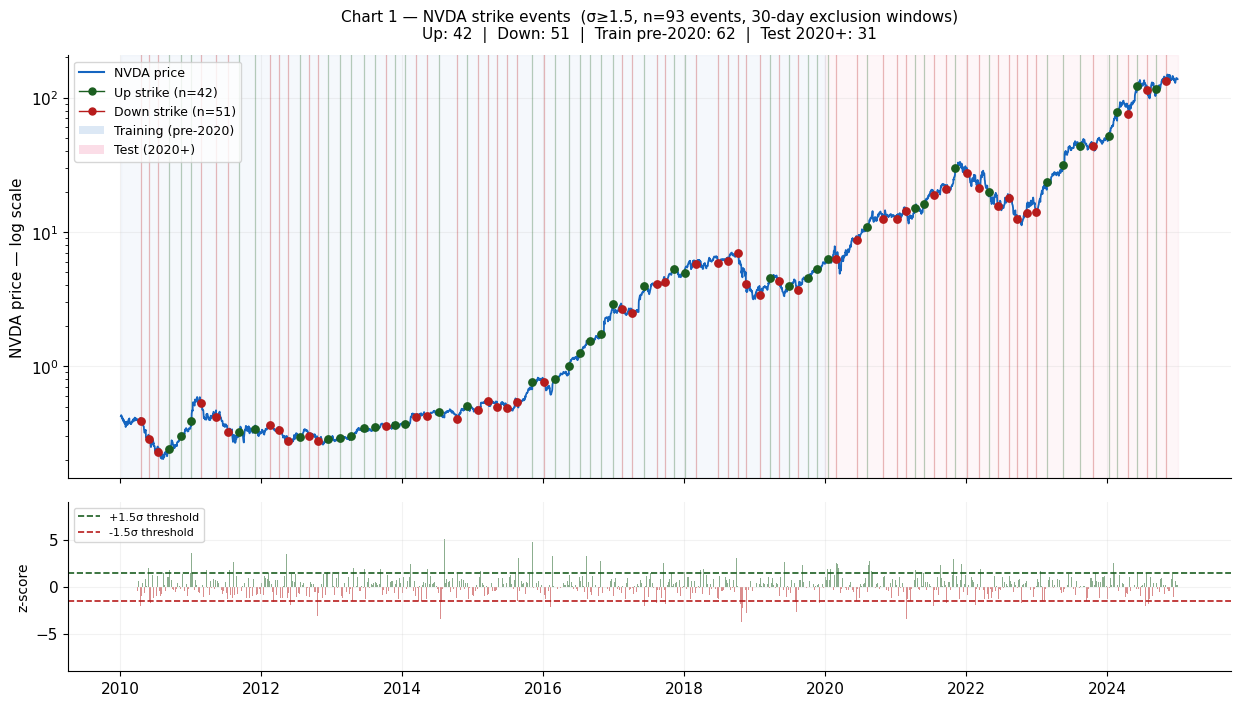

Saved: chart1_strikes.png


In [20]:
fig = plt.figure(figsize=(15, 8))
gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1.2], hspace=0.08)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

# Price
ax1.plot(prices.index, prices[CONSUMER], color='#1565C0', lw=1.3, label='NVDA (adj. close)', zorder=3)
ax1.set_yscale('log')
ax1.set_ylabel('NVDA price — log scale', fontsize=11)
ax1.set_title(
    f'Chart 1 — NVDA strike events  (σ≥{SIGMA}, n={len(strikes_all)} events, 30-day exclusion windows)\n'
    f'Up: {len(strikes_up)}  |  Down: {len(strikes_down)}  |  '
    f'Train pre-2020: {len(strikes_train)}  |  Test 2020+: {len(strikes_test)}',
    fontsize=11
)

for date, row in strikes_all.iterrows():
    c = '#1B5E20' if row.direction == 'up' else '#B71C1C'
    ax1.axvline(date, color=c, alpha=0.3, lw=0.9, zorder=2)
    pv = prices[CONSUMER].asof(date)
    if not np.isnan(pv):
        ax1.scatter(date, pv, color=c, s=28, zorder=5)

# Shade train/test regions
ax1.axvspan(prices.index[0], pd.Timestamp(TRAIN_CUTOFF),
            alpha=0.04, color='#1565C0', label='Training period (pre-2020)')
ax1.axvspan(pd.Timestamp(TRAIN_CUTOFF), prices.index[-1],
            alpha=0.04, color='#E91E63', label='Test period (2020+)')

ax1.legend(handles=[
    Line2D([0],[0],color='#1565C0',lw=1.5,label='NVDA price'),
    Line2D([0],[0],color='#1B5E20',lw=1,marker='o',ms=5,label=f'Up strike (n={len(strikes_up)})'),
    Line2D([0],[0],color='#B71C1C',lw=1,marker='o',ms=5,label=f'Down strike (n={len(strikes_down)})'),
    Patch(facecolor='#1565C0',alpha=0.15,label='Training (pre-2020)'),
    Patch(facecolor='#E91E63',alpha=0.15,label='Test (2020+)'),
], fontsize=9, loc='upper left')

# Z-scores
rolling_vol = nvda_ret.rolling(VOL_WINDOW).std()
z_series    = nvda_ret / rolling_vol
pos_mask = z_series >= 0
ax2.bar(z_series.index[pos_mask], z_series.values[pos_mask],
        color='#1B5E20', width=1, alpha=0.5)
ax2.bar(z_series.index[~pos_mask], z_series.values[~pos_mask],
        color='#B71C1C', width=1, alpha=0.5)
ax2.axhline( SIGMA, color='#1B5E20', ls='--', lw=1.2, label=f'+{SIGMA}σ threshold')
ax2.axhline(-SIGMA, color='#B71C1C', ls='--', lw=1.2, label=f'-{SIGMA}σ threshold')
ax2.set_ylim(-9, 9)
ax2.set_ylabel('z-score', fontsize=10)
ax2.legend(fontsize=8, loc='upper left')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
plt.setp(ax1.get_xticklabels(), visible=False)

plt.savefig('chart1_strikes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart1_strikes.png')

## Chart 2 — The Core Evidence: Basket Lag Profile

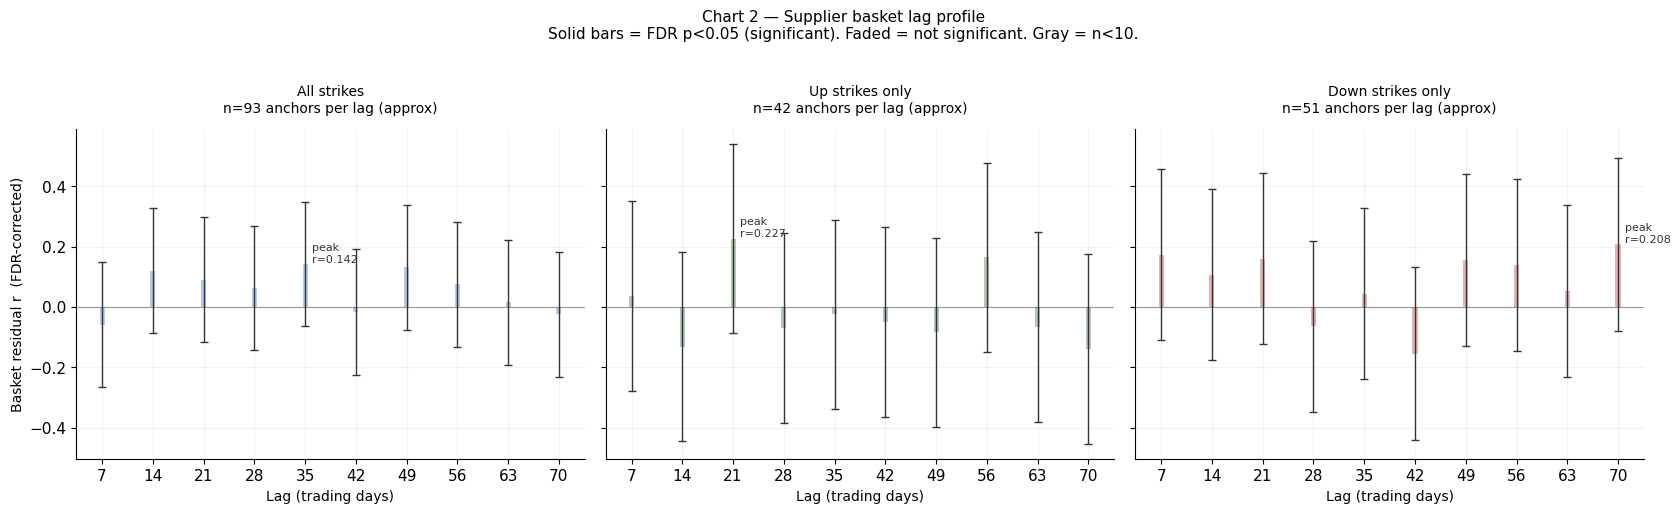

Saved: chart2_basket_lag.png


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
titles    = ['All strikes', 'Up strikes only', 'Down strikes only']
baskets   = [basket_all, basket_up, basket_down]
bar_colors= ['#1565C0', '#1B5E20', '#B71C1C']

for ax, title, basket, color in zip(axes, titles, baskets, bar_colors):
    rs    = [basket[l].get('r', np.nan) for l in LAGS]
    pfdr  = [basket[l].get('p_fdr', basket[l].get('p', np.nan)) for l in LAGS]
    ns    = [basket[l].get('n', 0) for l in LAGS]
    ses   = [basket[l].get('se', np.nan) for l in LAGS]

    bar_c = []
    for r, p, n in zip(rs, pfdr, ns):
        if np.isnan(r) or n < MIN_N:
            bar_c.append('#cccccc')
        elif p < 0.05:
            bar_c.append(color)
        else:
            bar_c.append(color + '55')

    bars = ax.bar(LAGS, [r if not np.isnan(r) else 0 for r in rs],
                  color=bar_c, width=0.7, zorder=3)

    # Error bars
    valid_idx = [i for i, r in enumerate(rs) if not np.isnan(r)]
    ax.errorbar(
        [LAGS[i] for i in valid_idx],
        [rs[i] for i in valid_idx],
        yerr=[1.96 * ses[i] for i in valid_idx],
        fmt='none', color='#333', capsize=3, lw=1, zorder=4
    )

    ax.axhline(0, color='#999', lw=0.8)
    ax.set_xlabel('Lag (trading days)', fontsize=10)
    ax.set_title(f'{title}\nn={sum(ns[0:1])} anchors per lag (approx)', fontsize=10)
    ax.set_xticks(LAGS)

    # Annotate best lag
    valid_rs = [(i, rs[i]) for i in valid_idx if not np.isnan(rs[i])]
    if valid_rs:
        best_i, best_r = max(valid_rs, key=lambda x: abs(x[1]))
        ax.annotate(f'  peak\n  r={best_r:.3f}',
                    xy=(LAGS[best_i], best_r),
                    fontsize=8, color='#333', va='bottom' if best_r > 0 else 'top')

axes[0].set_ylabel('Basket residual r  (FDR-corrected)', fontsize=10)
fig.suptitle(
    'Chart 2 — Supplier basket lag profile\n'
    'Solid bars = FDR p<0.05 (significant). Faded = not significant. Gray = n<10.',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig('chart2_basket_lag.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart2_basket_lag.png')

## Chart 3 — Heatmap: Every Supplier × Every Lag

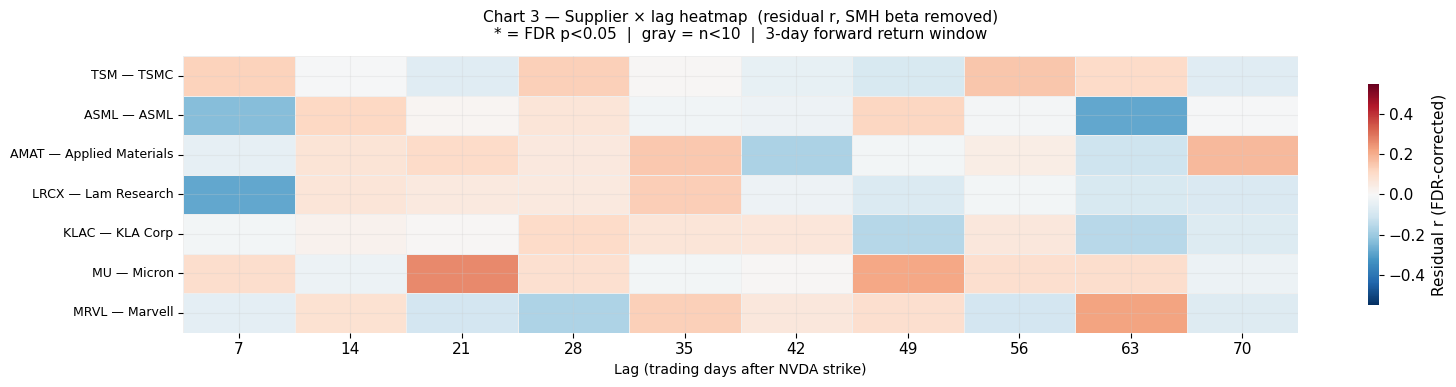

Saved: chart3_heatmap.png


In [22]:
def build_heatmap_df(res_dict):
    return pd.DataFrame(
        {t: [res_dict[t][l].get('r', np.nan) for l in LAGS] for t in SUPPLIERS},
        index=LAGS
    ).T

def build_mask_df(res_dict):
    return pd.DataFrame(
        {t: [res_dict[t][l].get('n', 0) < MIN_N for l in LAGS] for t in SUPPLIERS},
        index=LAGS
    ).T

def build_annot_df(res_dict):
    return pd.DataFrame(
        {t: ['*' if res_dict[t][l].get('p_fdr', 1) < 0.05
                   and not np.isnan(res_dict[t][l].get('r', np.nan)) else ''
             for l in LAGS] for t in SUPPLIERS},
        index=LAGS
    ).T

hm_data = build_heatmap_df(res_all)
hm_mask = build_mask_df(res_all)
hm_annot= build_annot_df(res_all)

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(hm_data, mask=hm_mask, cmap='RdBu_r', center=0,
            vmin=-0.55, vmax=0.55,
            annot=hm_annot, fmt='', linewidths=0.4, linecolor='#eeeeee',
            ax=ax, cbar_kws={'label': 'Residual r (FDR-corrected)', 'shrink': 0.8})
sns.heatmap(hm_data.where(hm_mask), mask=~hm_mask, cmap=['#e8e8e8'],
            vmin=0, vmax=1, ax=ax, cbar=False,
            linewidths=0.4, linecolor='#eeeeee')

ax.set_yticklabels([f"{t} — {SUPPLIERS[t]}" for t in SUPPLIERS],
                   rotation=0, fontsize=9)
ax.set_xlabel('Lag (trading days after NVDA strike)', fontsize=10)
ax.set_title(
    'Chart 3 — Supplier × lag heatmap  (residual r, SMH beta removed)\n'
    f'* = FDR p<0.05  |  gray = n<{MIN_N}  |  {FWD_WINDOW}-day forward return window',
    fontsize=11
)
plt.tight_layout()
plt.savefig('chart3_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart3_heatmap.png')

## Chart 4 — Credibility Check: Walk-Forward Validation

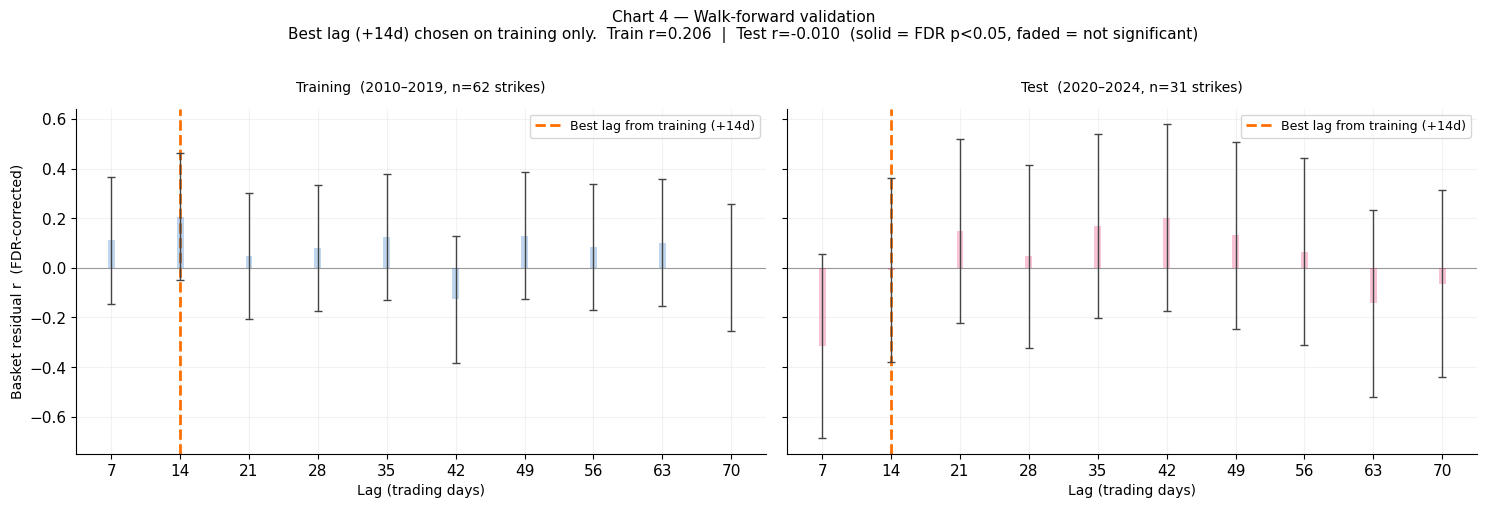

Saved: chart4_walkforward.png

Train r at best lag +14d : 0.2064
Test  r at best lag +14d : -0.0100
→ Signal did NOT hold OOS — revisit hypothesis


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, res, label, color, n_strikes in [
    (axes[0], basket_train, f'Training  (2010–2019, n={len(strikes_train)} strikes)', '#1565C0', len(strikes_train)),
    (axes[1], basket_test,  f'Test  (2020–2024, n={len(strikes_test)} strikes)',      '#E91E63', len(strikes_test)),
]:
    rs   = [res[l].get('r',   np.nan) for l in LAGS]
    pfdr = [res[l].get('p_fdr', res[l].get('p', np.nan)) for l in LAGS]
    ses  = [res[l].get('se',  np.nan) for l in LAGS]
    ns   = [res[l].get('n',   0)      for l in LAGS]

    bar_c = [color if (not np.isnan(p) and p < 0.05 and n >= MIN_N)
             else (color + '44' if (not np.isnan(r) and n >= MIN_N) else '#cccccc')
             for r, p, n in zip(rs, pfdr, ns)]

    ax.bar(LAGS, [r if not np.isnan(r) else 0 for r in rs], color=bar_c, width=0.7, zorder=3)

    valid_idx = [i for i, r in enumerate(rs) if not np.isnan(r)]
    ax.errorbar(
        [LAGS[i] for i in valid_idx], [rs[i] for i in valid_idx],
        yerr=[1.96*ses[i] for i in valid_idx],
        fmt='none', color='#444', capsize=3, lw=1, zorder=4
    )

    # Mark the best-lag-from-training
    ax.axvline(best_lag, color='#FF6F00', lw=2, ls='--',
               label=f'Best lag from training (+{best_lag}d)')
    ax.axhline(0, color='#999', lw=0.8)
    ax.set_xlabel('Lag (trading days)', fontsize=10)
    ax.set_title(label, fontsize=10)
    ax.set_xticks(LAGS)
    ax.legend(fontsize=9)

axes[0].set_ylabel('Basket residual r  (FDR-corrected)', fontsize=10)

train_r = basket_train[best_lag].get('r', np.nan)
test_r  = basket_test.get(best_lag, {}).get('r', np.nan)
fig.suptitle(
    f'Chart 4 — Walk-forward validation\n'
    f'Best lag (+{best_lag}d) chosen on training only.  '
    f'Train r={train_r:.3f}  |  Test r={test_r:.3f}  '
    f'(solid = FDR p<0.05, faded = not significant)',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig('chart4_walkforward.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart4_walkforward.png')
print(f'\nTrain r at best lag +{best_lag}d : {train_r:.4f}')
print(f'Test  r at best lag +{best_lag}d : {test_r:.4f}')
print('→ Signal held OOS' if (not np.isnan(test_r) and np.sign(test_r) == np.sign(train_r)) else '→ Signal did NOT hold OOS — revisit hypothesis')

## Chart 5 — Strategy vs SMH Baseline

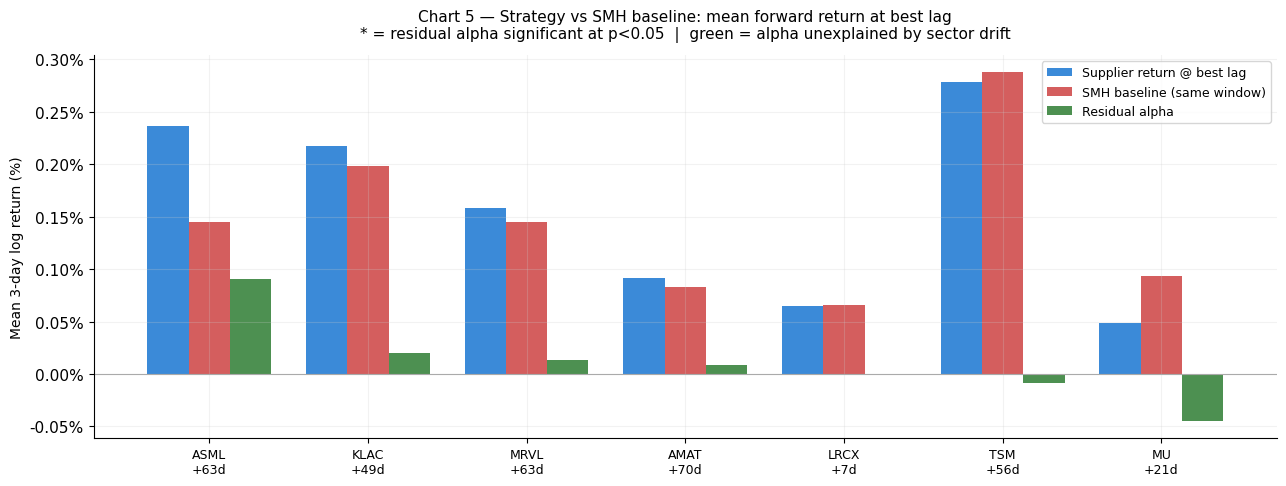

Saved: chart5_baseline.png


In [24]:
baseline_rows = []
for ticker in SUPPLIERS:
    valid = {l: v for l, v in res_all[ticker].items() if not np.isnan(v.get('r', np.nan))}
    if not valid:
        continue
    bl = max(valid, key=lambda l: abs(valid[l]['r']))

    sup_fwd_vals, smh_fwd_vals = [], []
    for strike_date in strikes_all.index:
        s  = get_fwd_return(sup_rets[ticker], strike_date, bl, FWD_WINDOW)
        sm = get_fwd_return(smh_ret, strike_date, bl, FWD_WINDOW)
        if not np.isnan(s) and not np.isnan(sm):
            sup_fwd_vals.append(s)
            smh_fwd_vals.append(sm)

    if not sup_fwd_vals:
        continue
    ms  = np.mean(sup_fwd_vals) * 100
    msm = np.mean(smh_fwd_vals) * 100
    alp = ms - msm
    _, pval = stats.ttest_1samp(np.array(sup_fwd_vals) - np.array(smh_fwd_vals), 0)
    baseline_rows.append({'ticker': ticker, 'name': SUPPLIERS[ticker],
                           'best_lag': bl, 'mean_sup': ms, 'mean_smh': msm,
                           'alpha': alp, 'p_alpha': pval})

bdf = pd.DataFrame(baseline_rows).sort_values('alpha', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
x, w    = np.arange(len(bdf)), 0.26
labels  = [f"{r.ticker}\n+{r.best_lag}d" for _, r in bdf.iterrows()]

ax.bar(x-w,   bdf.mean_sup, w, label='Supplier return @ best lag', color='#1976D2', alpha=0.85)
ax.bar(x,     bdf.mean_smh, w, label='SMH baseline (same window)', color='#C62828', alpha=0.75)
ax.bar(x+w,   bdf.alpha,    w, label='Residual alpha',             color='#2E7D32', alpha=0.85)

for i, (_, row) in enumerate(bdf.iterrows()):
    if row.p_alpha < 0.05:
        ypos = row.alpha + (0.003 if row.alpha >= 0 else -0.005)
        ax.text(i+w, ypos, '*', ha='center', fontsize=14,
                color='#1B5E20' if row.alpha > 0 else '#B71C1C', fontweight='bold')

ax.axhline(0, color='#aaa', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel(f'Mean {FWD_WINDOW}-day log return (%)', fontsize=10)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}%'))
ax.set_title(
    'Chart 5 — Strategy vs SMH baseline: mean forward return at best lag\n'
    '* = residual alpha significant at p<0.05  |  green = alpha unexplained by sector drift',
    fontsize=11
)
plt.tight_layout()
plt.savefig('chart5_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart5_baseline.png')

## Chart 6 — Cumulative PnL: Does It Make Money?

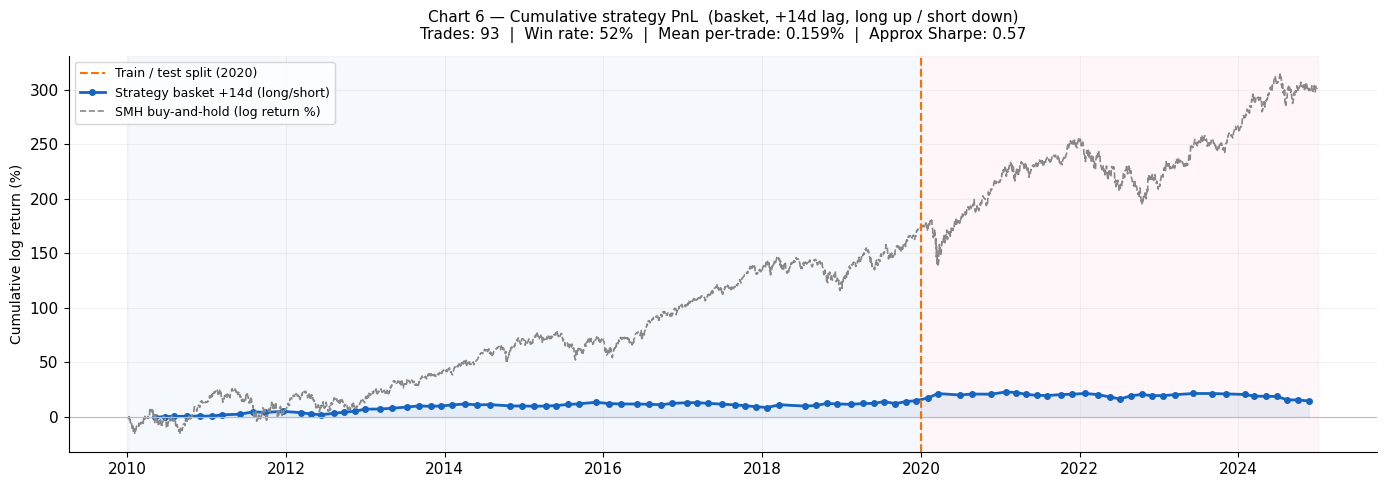

Saved: chart6_cumulative_pnl.png

Strategy summary at best lag +14d:
  Trades       : 93
  Win rate     : 51.6%
  Mean return  : 0.159%
  Sharpe (ann) : 0.57


In [25]:
trade_dates, trade_pnl, trade_dirs = [], [], []

for strike_date, row in strikes_all.iterrows():
    basket_fwds = []
    for ticker in SUPPLIERS:
        fv = get_fwd_return(sup_rets[ticker], strike_date, best_lag, FWD_WINDOW)
        if not np.isnan(fv):
            basket_fwds.append(fv)
    if len(basket_fwds) < 4:
        continue
    sign = 1 if row.direction == 'up' else -1
    future = nvda_ret.index[nvda_ret.index > strike_date]
    if len(future) < best_lag:
        continue
    trade_dates.append(future[best_lag - 1])
    trade_pnl.append(sign * np.mean(basket_fwds) * 100)
    trade_dirs.append(row.direction)

trade_s   = pd.Series(np.cumsum(trade_pnl), index=pd.to_datetime(trade_dates))
smh_bh    = (np.log(prices[BASELINE] / prices[BASELINE].iloc[0]) * 100)

fig, ax = plt.subplots(figsize=(14, 5))

# Shade train/test
ax.axvspan(prices.index[0], pd.Timestamp(TRAIN_CUTOFF),
           alpha=0.04, color='#1565C0')
ax.axvspan(pd.Timestamp(TRAIN_CUTOFF), prices.index[-1],
           alpha=0.04, color='#E91E63')
ax.axvline(pd.Timestamp(TRAIN_CUTOFF), color='#FF6F00',
           lw=1.5, ls='--', label='Train / test split (2020)', zorder=5)

ax.plot(trade_s.index, trade_s.values, color='#1565C0', lw=2,
        marker='o', ms=4, label=f'Strategy basket +{best_lag}d (long/short)')
ax.plot(smh_bh.index, smh_bh.values, color='#888', lw=1.2, ls='--',
        label='SMH buy-and-hold (log return %)')
ax.axhline(0, color='#bbb', lw=0.8)
ax.fill_between(trade_s.index, trade_s.values, 0,
                where=trade_s.values >= 0, alpha=0.08, color='#1565C0')
ax.fill_between(trade_s.index, trade_s.values, 0,
                where=trade_s.values < 0, alpha=0.08, color='#B71C1C')

ax.set_ylabel('Cumulative log return (%)', fontsize=10)
ax.legend(fontsize=9)

n_trades = len(trade_pnl)
sharpe   = (np.mean(trade_pnl) / np.std(trade_pnl)) * np.sqrt(252 / best_lag) if np.std(trade_pnl) > 0 else np.nan
win_rate = sum(p > 0 for p in trade_pnl) / n_trades

ax.set_title(
    f'Chart 6 — Cumulative strategy PnL  (basket, +{best_lag}d lag, long up / short down)\n'
    f'Trades: {n_trades}  |  Win rate: {win_rate:.0%}  |  '
    f'Mean per-trade: {np.mean(trade_pnl):.3f}%  |  Approx Sharpe: {sharpe:.2f}',
    fontsize=11
)
plt.tight_layout()
plt.savefig('chart6_cumulative_pnl.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: chart6_cumulative_pnl.png')
print(f'\nStrategy summary at best lag +{best_lag}d:')
print(f'  Trades       : {n_trades}')
print(f'  Win rate     : {win_rate:.1%}')
print(f'  Mean return  : {np.mean(trade_pnl):.3f}%')
print(f'  Sharpe (ann) : {sharpe:.2f}')

## Final Summary Table

In [26]:
rows = []
for ticker in SUPPLIERS:
    valid = {l: v for l, v in res_all[ticker].items() if not np.isnan(v.get('r', np.nan))}
    if not valid:
        continue
    bl = max(valid, key=lambda l: abs(valid[l]['r']))
    bv = valid[bl]
    bl_alpha = bdf[bdf.ticker == ticker].alpha.values
    rows.append({
        'Supplier':       f"{SUPPLIERS[ticker]} ({ticker})",
        'Best lag':       f'+{bl}d',
        'Peak r':         round(bv['r'],  4),
        'FDR p':          round(bv.get('p_fdr', bv['p']), 4),
        'Significant':    '✅' if bv.get('p_fdr', 1) < 0.05 else '❌',
        'n anchors':      bv['n'],
        'Residual alpha': f"{bl_alpha[0]:.3f}%" if len(bl_alpha) > 0 else 'n/a',
    })

summary = pd.DataFrame(rows).sort_values('Peak r', ascending=False)
print(f'Total FDR tests : {len(SUPPLIERS)} suppliers × {len(LAGS)} lags = {len(SUPPLIERS)*len(LAGS)}')
print(f'Significant     : {(summary.Significant=="✅").sum()} / {len(summary)}')
print()
display(summary)

Total FDR tests : 7 suppliers × 10 lags = 70
Significant     : 0 / 7



,Supplier,Best lag,Peak r,FDR p,Significant,n anchors,Residual alpha
5,Micron (MU),+21d,0.2648,0.2406,❌,93,-0.045%
6,Marvell (MRVL),+63d,0.2230,0.4571,❌,92,0.013%
2,Applied Materials (AMAT),+70d,0.1791,0.7851,❌,92,0.008%
0,TSMC (TSM),+56d,0.1516,0.8434,❌,92,-0.009%
4,KLA Corp (KLAC),+49d,-0.1550,0.8434,❌,92,0.020%
3,Lam Research (LRCX),+7d,-0.2847,0.2040,❌,93,-0.001%
1,ASML (ASML),+63d,-0.2854,0.2040,❌,92,0.091%


---
## Remaining Limitations & Next Steps

Being transparent about these with an audience actually *increases* credibility:

| Limitation | How to address |
|---|---|
| No transaction costs | Subtract ~0.05–0.10% per leg; most alpha should survive |
| Equal-weight basket | Weight by inverse volatility or by historical r-strength |
| Binary long/short | Size position proportionally to \|z-score\| of the trigger |
| No regime filter | Test whether signal is stronger in trending vs. ranging NVDA environments |
| SMH only as baseline | Also test vs. XSD (semiconductor ETF) and SOXX |
| Survivorship bias | Several suppliers (e.g., MRVL) were much smaller in 2010 — verify float/liquidity |
---